# BeetleCast 08 — Spatial robustness and leakage audit

This is the final technical pressure test.

It asks:

1. Does the temporal-AEF model remain strong with larger spatial blocks?
2. Does it remain useful after removing training patches close to the test area?
3. Can geographic coordinates alone predict the labels?

The notebook evaluates the same historically stable-forest population used in notebook 04.

Models:

- **Coordinate-only diagnostic:** patch row, patch column, and label year
- **BeetleCast:** Sentinel-2 temporal features + temporal AlphaEarth features

Validation:

- 1 km and 2 km spatial blocks
- multiple random spatial splits
- optional 500 m train/test exclusion buffer

A strong result is:

- BeetleCast remains useful under larger blocks and buffering;
- BeetleCast clearly outperforms the coordinate-only diagnostic.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")

PATCH_SIZE_METRES = 50
TEST_FRACTION = 0.25

# 20 patches = 1 km; 40 patches = 2 km.
BLOCK_SIZES_PATCHES = [20, 40]

# Repeated spatial splits.
SEEDS = [11, 22, 33, 44, 55]

# 0 patches = ordinary blocked split.
# 10 patches = remove training samples within about 500 m of test samples.
BUFFER_SIZES_PATCHES = [0, 10]

cwd = Path.cwd()
if (cwd / "hackathon_data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "hackathon_data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not find hackathon_data/. Launch Jupyter from project_root."
    )

INPUT_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "lulc"
    / "beetlecast_training_table_with_lulc.csv"
)

OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "spatial_robustness"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


PROJECT_ROOT: /Users/hemat/Desktop/hackathon-demo
INPUT_PATH: /Users/hemat/Desktop/hackathon-demo/outputs/lulc/beetlecast_training_table_with_lulc.csv
OUTPUT_ROOT: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_robustness


## 1. Load the stable-forest training population

In [2]:
assert INPUT_PATH.exists(), (
    "Missing outputs/lulc/beetlecast_training_table_with_lulc.csv. "
    "Run notebook 04 first."
)

data = pd.read_csv(INPUT_PATH)

baseline_features = [
    "ndvi_recent",
    "ndre_recent",
    "nbr_recent",
    "ndvi_prior",
    "ndre_prior",
    "nbr_prior",
    "ndvi_change",
    "ndre_change",
    "nbr_change",
    "ndvi_std",
    "ndre_std",
    "valid_fraction",
]

temporal_aef_features = sorted([
    column for column in data.columns
    if column.startswith("aef_")
])

beetlecast_features = baseline_features + temporal_aef_features
coordinate_features = ["patch_row", "patch_col", "label_year"]

if data["stable_forest"].dtype == object:
    data["stable_forest"] = (
        data["stable_forest"]
        .astype(str)
        .str.lower()
        .eq("true")
    )

required = {
    "stable_forest",
    "target",
    "patch_row",
    "patch_col",
    "label_year",
} | set(beetlecast_features)

missing = required - set(data.columns)
assert not missing, f"Missing columns: {missing}"

stable = data[
    data["stable_forest"]
].dropna(
    subset=beetlecast_features
    + coordinate_features
    + ["target"]
).copy()

stable["target"] = stable["target"].astype(int)
stable["patch_row"] = stable["patch_row"].astype(int)
stable["patch_col"] = stable["patch_col"].astype(int)
stable["label_year"] = stable["label_year"].astype(int)

print("Rows:", len(stable))
print("Positive rate:", round(stable["target"].mean(), 3))
print("BeetleCast features:", len(beetlecast_features))
print(stable.groupby(["label_year", "target"]).size())


Rows: 16092
Positive rate: 0.257
BeetleCast features: 332
label_year  target
2022        0         5824
            1         2103
2023        0         6139
            1         2026
dtype: int64


## 2. Evaluation helpers

In [3]:
def top_fraction_capture(y_true, risk, fraction=0.10):
    y_true = np.asarray(y_true).astype(int)
    risk = np.asarray(risk)

    if y_true.sum() == 0:
        return np.nan

    n_select = max(1, int(np.ceil(len(risk) * fraction)))
    selected = np.argsort(risk)[-n_select:]

    return float(y_true[selected].sum() / y_true.sum())

def make_groups(frame, block_size_patches):
    block_row = frame["patch_row"] // block_size_patches
    block_col = frame["patch_col"] // block_size_patches

    return (
        block_row.astype(str)
        + "_"
        + block_col.astype(str)
    )

def apply_spatial_buffer(train, test, buffer_patches):
    if buffer_patches <= 0:
        return train.copy()

    test_xy = test[["patch_row", "patch_col"]].to_numpy()
    train_xy = train[["patch_row", "patch_col"]].to_numpy()

    nearest = NearestNeighbors(
        n_neighbors=1,
        algorithm="auto",
    )
    nearest.fit(test_xy)

    distances, _ = nearest.kneighbors(train_xy)
    distances = distances[:, 0]

    keep = distances >= buffer_patches

    return train.iloc[np.where(keep)[0]].copy()

def fit_model(train, features):
    model = HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=350,
        max_leaf_nodes=31,
        min_samples_leaf=25,
        l2_regularization=2.0,
        random_state=42,
    )

    weights = compute_sample_weight(
        class_weight="balanced",
        y=train["target"],
    )

    model.fit(
        train[features],
        train["target"],
        sample_weight=weights,
    )

    return model

def score_model(model, test, features):
    risk = model.predict_proba(test[features])[:, 1]
    y_true = test["target"].to_numpy()

    return {
        "pr_auc": average_precision_score(y_true, risk),
        "roc_auc": roc_auc_score(y_true, risk),
        "top_10_capture": top_fraction_capture(
            y_true,
            risk,
            fraction=0.10,
        ),
    }


## 3. Run repeated large-block and buffered evaluations

Both models use exactly the same train/test rows for every experiment.


In [4]:
results = []

for block_size in BLOCK_SIZES_PATCHES:
    groups = make_groups(stable, block_size)

    for seed in SEEDS:
        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=TEST_FRACTION,
            random_state=seed,
        )

        train_idx, test_idx = next(
            splitter.split(
                stable,
                stable["target"],
                groups,
            )
        )

        base_train = stable.iloc[train_idx].copy()
        test = stable.iloc[test_idx].copy()

        # Skip invalid splits that contain only one class.
        if (
            base_train["target"].nunique() < 2
            or test["target"].nunique() < 2
        ):
            print(
                "Skipping single-class split:",
                block_size,
                seed,
            )
            continue

        for buffer_patches in BUFFER_SIZES_PATCHES:
            train = apply_spatial_buffer(
                base_train,
                test,
                buffer_patches,
            )

            if (
                len(train) < 100
                or train["target"].nunique() < 2
            ):
                print(
                    "Skipping insufficient buffered split:",
                    block_size,
                    seed,
                    buffer_patches,
                )
                continue

            experiments = [
                (
                    "Coordinate-only diagnostic",
                    coordinate_features,
                ),
                (
                    "BeetleCast temporal AEF",
                    beetlecast_features,
                ),
            ]

            for model_name, features in experiments:
                model = fit_model(train, features)
                metrics = score_model(model, test, features)

                results.append({
                    "model": model_name,
                    "block_size_patches": block_size,
                    "block_size_metres": (
                        block_size * PATCH_SIZE_METRES
                    ),
                    "buffer_patches": buffer_patches,
                    "buffer_metres": (
                        buffer_patches * PATCH_SIZE_METRES
                    ),
                    "seed": seed,
                    "train_rows": len(train),
                    "test_rows": len(test),
                    "train_positive_rate": train["target"].mean(),
                    "test_positive_rate": test["target"].mean(),
                    **metrics,
                })

results_df = pd.DataFrame(results)

assert not results_df.empty, "No valid experiments completed."

results_path = (
    OUTPUT_ROOT
    / "beetlecast_spatial_robustness_all_runs.csv"
)
results_df.to_csv(results_path, index=False)

display(results_df.head())
print("Completed model fits:", len(results_df))
print("Saved:", results_path)


,model,block_size_patches,block_size_metres,buffer_patches,buffer_metres,seed,train_rows,test_rows,train_positive_rate,test_positive_rate,pr_auc,roc_auc,top_10_capture
0,Coordinate-only diagnostic,20,1000,0,0,11,12430,3662,0.291633,0.137630,0.600755,0.878750,0.468254
1,BeetleCast temporal AEF,20,1000,0,0,11,12430,3662,0.291633,0.137630,0.822854,0.940353,0.628968
2,Coordinate-only diagnostic,20,1000,10,500,11,7047,3662,0.316872,0.137630,0.354907,0.785135,0.283730
3,BeetleCast temporal AEF,20,1000,10,500,11,7047,3662,0.316872,0.137630,0.702745,0.879626,0.533730
4,Coordinate-only diagnostic,20,1000,0,0,22,11489,4603,0.255288,0.259831,0.839676,0.919076,0.352007


Completed model fits: 40
Saved: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_robustness/beetlecast_spatial_robustness_all_runs.csv


## 4. Summarise mean performance and variability

In [5]:
summary = (
    results_df.groupby(
        [
            "model",
            "block_size_metres",
            "buffer_metres",
        ]
    )
    .agg(
        runs=("seed", "count"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        top10_mean=("top_10_capture", "mean"),
        top10_std=("top_10_capture", "std"),
        train_rows_mean=("train_rows", "mean"),
        test_rows_mean=("test_rows", "mean"),
    )
    .reset_index()
)

summary_path = (
    OUTPUT_ROOT
    / "beetlecast_spatial_robustness_summary.csv"
)
summary.to_csv(summary_path, index=False)

display(
    summary.sort_values(
        ["block_size_metres", "buffer_metres", "model"]
    )
)

print("Saved:", summary_path)


,model,block_size_metres,buffer_metres,runs,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,top10_mean,top10_std,train_rows_mean,test_rows_mean
0,BeetleCast temporal AEF,1000,0,5,0.887974,0.042703,0.949819,0.010993,0.391781,0.143648,12020.4,4071.6
4,Coordinate-only diagnostic,1000,0,5,0.732824,0.113781,0.895987,0.022972,0.321889,0.093972,12020.4,4071.6
1,BeetleCast temporal AEF,1000,500,5,0.782051,0.053079,0.893569,0.019202,0.352858,0.112026,6268.6,4071.6
5,Coordinate-only diagnostic,1000,500,5,0.530460,0.153465,0.777911,0.056149,0.230629,0.050228,6268.6,4071.6
2,BeetleCast temporal AEF,2000,0,5,0.741436,0.176621,0.904318,0.038878,0.322376,0.036266,12002.6,4089.4
6,Coordinate-only diagnostic,2000,0,5,0.637654,0.207325,0.850027,0.059813,0.289654,0.031613,12002.6,4089.4
3,BeetleCast temporal AEF,2000,500,5,0.668586,0.197499,0.873591,0.048332,0.291120,0.041514,9356.2,4089.4
7,Coordinate-only diagnostic,2000,500,5,0.440804,0.172633,0.713578,0.069515,0.179516,0.058335,9356.2,4089.4


Saved: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_robustness/beetlecast_spatial_robustness_summary.csv


## 5. Compare BeetleCast with the coordinate-only diagnostic

A large coordinate-only score would indicate that geographic location or survey footprint explains much of the target. BeetleCast should outperform it, especially under 2 km blocks and the 500 m buffer.


In [6]:
comparison = summary.pivot_table(
    index=[
        "block_size_metres",
        "buffer_metres",
    ],
    columns="model",
    values=[
        "pr_auc_mean",
        "top10_mean",
    ],
)

display(comparison)

# Calculate the PR-AUC gain over coordinates for each setting.
pr_table = summary.pivot_table(
    index=[
        "block_size_metres",
        "buffer_metres",
    ],
    columns="model",
    values="pr_auc_mean",
)

if {
    "Coordinate-only diagnostic",
    "BeetleCast temporal AEF",
}.issubset(pr_table.columns):
    pr_table["beetlecast_pr_auc_gain"] = (
        pr_table["BeetleCast temporal AEF"]
        - pr_table["Coordinate-only diagnostic"]
    )

display(pr_table)


pr_auc_mean  \
model                           BeetleCast temporal AEF   
block_size_metres buffer_metres                           
1000              0                            0.887974   
                  500                          0.782051   
2000              0                            0.741436   
                  500                          0.668586   

                                                            \
model                           Coordinate-only diagnostic   
block_size_metres buffer_metres                              
1000              0                               0.732824   
                  500                             0.530460   
2000              0                               0.637654   
                  500                             0.440804   

                                             top10_mean  \
model                           BeetleCast temporal AEF   
block_size_metres buffer_metres                           
1000              0                            0.391781   
                  500                          0.352858   
2000              0                            0.322376   
                  500                          0.291120   

                                                            
model                           Coordinate-only diagnostic  
block_size_metres buffer_metres                             
1000              0                               0.321889  
                  500                             0.230629  
2000              0                               0.289654  
                  500                             0.179516

model                            BeetleCast temporal AEF  \
block_size_metres buffer_metres                            
1000              0                             0.887974   
                  500                           0.782051   
2000              0                             0.741436   
                  500                           0.668586   

model                            Coordinate-only diagnostic  \
block_size_metres buffer_metres                               
1000              0                                0.732824   
                  500                              0.530460   
2000              0                                0.637654   
                  500                              0.440804   

model                            beetlecast_pr_auc_gain  
block_size_metres buffer_metres                          
1000              0                            0.155149  
                  500                          0.251591  
2000              0                            0.103782  
                  500                          0.227782

## 6. Plot the robustness results

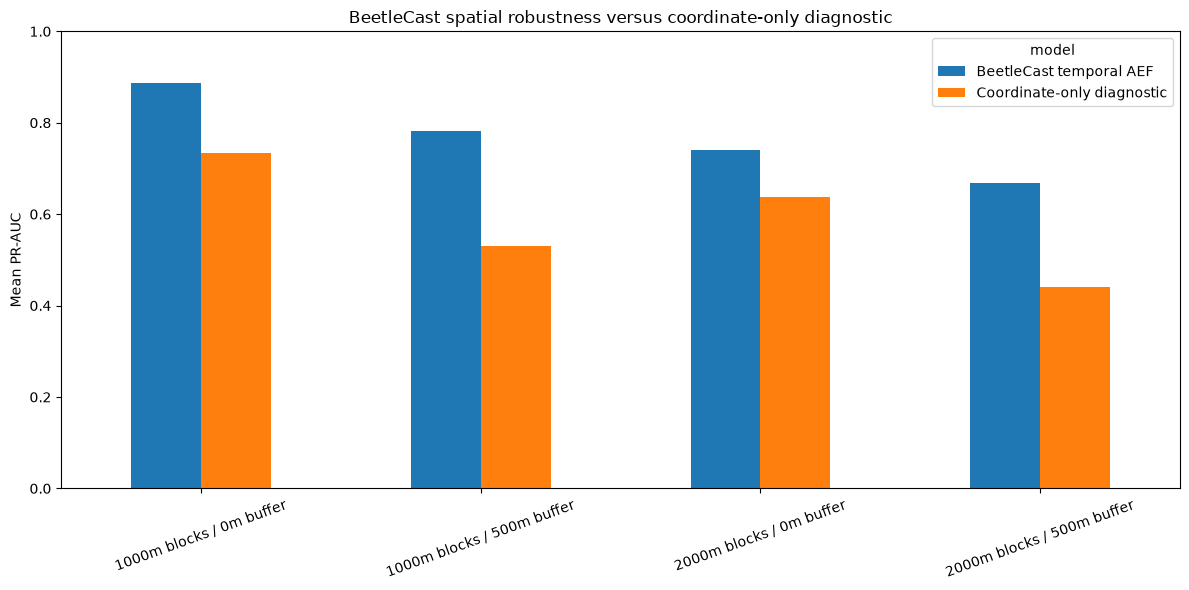

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_robustness/spatial_robustness_pr_auc.png


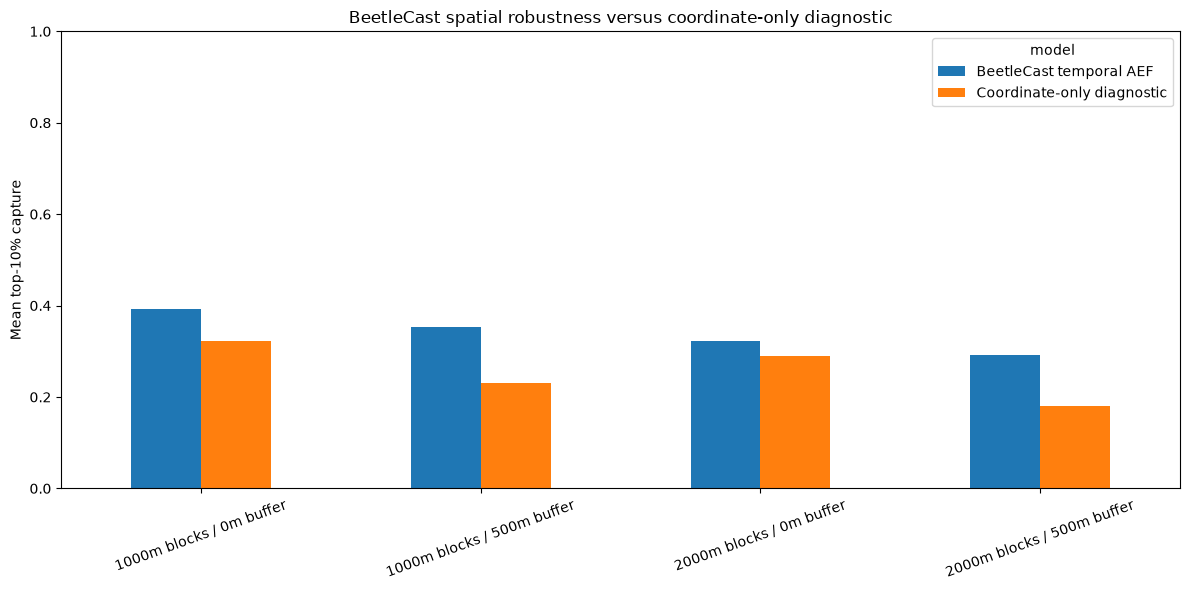

Saved: /Users/hemat/Desktop/hackathon-demo/outputs/spatial_robustness/spatial_robustness_top10_capture.png


In [7]:
plot_data = summary.copy()

plot_data["setting"] = (
    plot_data["block_size_metres"].astype(int).astype(str)
    + "m blocks / "
    + plot_data["buffer_metres"].astype(int).astype(str)
    + "m buffer"
)

for metric, ylabel, filename in [
    (
        "pr_auc_mean",
        "Mean PR-AUC",
        "spatial_robustness_pr_auc.png",
    ),
    (
        "top10_mean",
        "Mean top-10% capture",
        "spatial_robustness_top10_capture.png",
    ),
]:
    pivot = plot_data.pivot(
        index="setting",
        columns="model",
        values=metric,
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(12, 6),
        rot=20,
    )
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    ax.set_title(
        "BeetleCast spatial robustness versus coordinate-only diagnostic"
    )
    plt.tight_layout()

    figure_path = OUTPUT_ROOT / filename
    plt.savefig(
        figure_path,
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", figure_path)


## 7. Strictest-setting conclusion

The strictest setting here is:

- 2 km spatial blocks;
- 500 m exclusion buffer around held-out patches;
- mean over five spatial splits.


In [8]:
strict = summary[
    (summary["block_size_metres"] == 2000)
    & (summary["buffer_metres"] == 500)
].copy()

display(strict)

beetlecast_strict = strict[
    strict["model"] == "BeetleCast temporal AEF"
]

coordinate_strict = strict[
    strict["model"] == "Coordinate-only diagnostic"
]

print("SPATIAL ROBUSTNESS AUDIT COMPLETE")
print("---------------------------------")

if not beetlecast_strict.empty:
    row = beetlecast_strict.iloc[0]

    print(
        "BeetleCast strict PR-AUC:",
        f"{row.pr_auc_mean:.3f} ± "
        f"{row.pr_auc_std:.3f}",
    )
    print(
        "BeetleCast strict top-10% capture:",
        f"{row.top10_mean:.1%} ± "
        f"{row.top10_std:.1%}",
    )

if not coordinate_strict.empty:
    row = coordinate_strict.iloc[0]

    print(
        "Coordinate-only strict PR-AUC:",
        f"{row.pr_auc_mean:.3f} ± "
        f"{row.pr_auc_std:.3f}",
    )

if (
    not beetlecast_strict.empty
    and not coordinate_strict.empty
):
    gain = (
        beetlecast_strict.iloc[0].pr_auc_mean
        - coordinate_strict.iloc[0].pr_auc_mean
    )

    print(
        "BeetleCast PR-AUC gain over coordinates:",
        f"{gain:.3f}",
    )

    if gain >= 0.10:
        print(
            "\nDecision: strong evidence that the satellite "
            "features add predictive value beyond geography."
        )
    elif gain > 0:
        print(
            "\nDecision: satellite features outperform geography, "
            "but present the result with caution."
        )
    else:
        print(
            "\nWarning: coordinate-only performance matches or "
            "exceeds BeetleCast. Investigate survey-footprint leakage."
        )

print("\nUse the strict mean ± standard deviation in the final pitch.")


,model,block_size_metres,buffer_metres,runs,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,top10_mean,top10_std,train_rows_mean,test_rows_mean
3,BeetleCast temporal AEF,2000,500,5,0.668586,0.197499,0.873591,0.048332,0.291120,0.041514,9356.2,4089.4
7,Coordinate-only diagnostic,2000,500,5,0.440804,0.172633,0.713578,0.069515,0.179516,0.058335,9356.2,4089.4


SPATIAL ROBUSTNESS AUDIT COMPLETE
---------------------------------
BeetleCast strict PR-AUC: 0.669 ± 0.197
BeetleCast strict top-10% capture: 29.1% ± 4.2%
Coordinate-only strict PR-AUC: 0.441 ± 0.173
BeetleCast PR-AUC gain over coordinates: 0.228

Decision: strong evidence that the satellite features add predictive value beyond geography.

Use the strict mean ± standard deviation in the final pitch.
